# 01 — `emt_buses`: posiciones GPS de la flota

**Origen.** ArcGIS REST del geoportal del Ajuntament de València, capa
`EMT/Seguimiento_EMT/384`. Sondeo cada 30 s.

**Papel en el TFM.** Es la fuente de la variable objetivo. El retraso sale de
comparar dónde está un autobús con dónde debería estar según el horario teórico
del GTFS, así que **cualquier defecto de esta tabla contamina la etiqueta**, no
solo una feature.

**Trampas que aplican a esta capa** — abrir la ficha antes de tocar nada:

| id | qué |
|----|-----|
| [001](../../.claude/trampas/001-gid-no-identifica-vehiculo.md) | `gid` identifica al refresco, no al vehículo. Intersección cero entre sondeos |
| [002](../../.claude/trampas/002-emt-alterna-convencion-horaria.md) | La EMT alterna UTC y hora local naive de un sondeo al siguiente |
| [004](../../.claude/trampas/004-sort-inestable-en-snapshot.md) | `sort_values` reordena filas dentro del snapshot y rompe el reenganche por posición |
| [006](../../.claude/trampas/006-posiciones-fuera-de-caja-no-son-error.md) | Las posiciones al sur de 39,36° son líneas reales, no error de GPS |

Este notebook es de los profundos: `emt_buses` y `trafico_estado` son la
hipótesis del TFM, las otras tres son contexto.

In [1]:
import sys
from pathlib import Path

# El notebook debe correr tanto abierto desde notebooks/EDA como ejecutado
# desde la raíz del repo (nbclient, CI).
AQUI = Path("notebooks/EDA").resolve() if Path("notebooks/EDA").exists() else Path.cwd()
sys.path.insert(0, str(AQUI))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import eda_utils as eu

eu.estilo()
FUENTE = "emt_buses"
print("corpus:", eu.dir_fuente(FUENTE))

corpus: C:\Users\oppen\Code\TFM\data\curated\source=emt_buses


## 1. Censo y esquema

In [2]:
eu.censo(FUENTE)

,valor
métrica,
fuente,emt_buses
filas,"5,163,031"
ficheros parquet,679
particiones (días),17
tamaño en disco,119.0 MB
ts_utc mínimo,2026-08-15 20:14:10+00:00
ts_utc máximo,2026-08-31 16:29:55+00:00


In [3]:
eu.esquema(FUENTE)

columna,tipo,descripcion
snapshot_id,BIGINT,identifica el sondeo: es el `gid` mínimo del bloque (trampa 001)
gid,BIGINT,"OID de la tabla, único en el refresco pero **no identifica al vehículo**: la tabla se trunca y reinserta entera (trampa 001)"
linea,VARCHAR,"número de línea tal como lo publica la EMT (`70`, `C3`)"
trayecto,VARCHAR,línea + sentido en texto (`Alboraia - La Fontsanta`); no casa por clave con el GTFS
lat,DOUBLE,"latitud WGS84 (`outSR=4326`, sin reproyectar)"
lon,DOUBLE,longitud WGS84
ts_utc,TIMESTAMP WITH TIME ZONE,"instante del dato **según la fuente**, normalizado a UTC"
ts_ingest_utc,TIMESTAMP WITH TIME ZONE,instante en que el colector recibió la respuesta (su propio reloj)
latencia_s,DOUBLE,`ts_ingest_utc − ts_utc`: antigüedad del dato al capturarlo
tz_convencion,VARCHAR,convención horaria detectada en ese snapshot (`utc` / `local`); la EMT **alterna** entre sondeos (trampa 002)


`snapshot_id` agrupa las filas de un mismo sondeo; `gid` es el identificador que
publica la fuente, y **no identifica al vehículo** (trampa 001): la tabla se
trunca y se reinserta entera en cada refresco. `tz_convencion` la añade el
colector al resolver la trampa 002, y `latencia_s` es
`ts_ingest_utc − ts_utc`.

## 2. Calidad: nulos, cardinalidad, columnas constantes

In [4]:
eu.perfil_nulos(FUENTE)

,columna,nulos,pct_nulos,distintos,constante
3,trayecto,1834,0.036,86,False
0,snapshot_id,0,0.000,40914,False
1,gid,0,0.000,5162058,False
2,linea,0,0.000,42,False
4,lat,0,0.000,1519609,False
5,lon,0,0.000,1519610,False
6,ts_utc,0,0.000,856374,False
7,ts_ingest_utc,0,0.000,40943,False
8,latencia_s,0,0.000,903222,False
9,tz_convencion,0,0.000,2,False


In [5]:
# La clave natural de una fila es (snapshot_id, gid). Si se repite, o el
# colector escribió dos veces el mismo sondeo, o gid no es único ni dentro del
# refresco — y eso cambiaría cómo hay que reconstruir la identidad.
eu.duplicados(FUENTE, ["snapshot_id", "gid"])

,filas,combinaciones_unicas,duplicadas
0,5163031,5162058,973


In [6]:
# Si la clave se repite, conviene ver dónde: unas pocas repeticiones aisladas
# son otra cosa que un patrón sistemático.
eu.sql(
    """
    WITH d AS (
        SELECT snapshot_id, gid, count(*) AS veces
        FROM {f} GROUP BY 1, 2 HAVING count(*) > 1
    )
    SELECT count(*) AS claves_repetidas,
           sum(veces) AS filas_implicadas,
           max(veces) AS repeticion_maxima,
           count(DISTINCT snapshot_id) AS snapshots_afectados
    FROM d
    """,
    f=FUENTE,
)

,claves_repetidas,filas_implicadas,repeticion_maxima,snapshots_afectados
0,676,"1,649.000",13,18


`(snapshot_id, gid)` **no es del todo única**, y el patrón dice de qué se trata:
las repeticiones se concentran en un puñado de snapshots de los más de cuarenta
mil, con hasta una decena de copias de la misma clave. No es una propiedad de la
fuente —si lo fuera, aparecería en todos los sondeos, como en la capa 192— sino un
puñado de sondeos escritos dos veces.

Da igual la causa para lo que toca decidir: `prepare.py` no puede dar por hecha la
unicidad. Cualquier `join` por esa clave duplicaría filas en silencio, así que hay
que deduplicar explícitamente y dejar constancia de cuántas cayeron.

## 3. Cobertura temporal y cadencia

`ts_ingest_utc` es el reloj del colector; `ts_utc` el de la fuente. Para medir
cada cuánto sondeamos, solo vale el primero.

In [7]:
eu.cadencia(FUENTE).round(1)

,sondeos,mediana_s,media_s,min_s,p95_s,max_s,huecos,horas_perdidas
0,40942,30.000,33.400,30,31.000,53500,30.000,30.700


In [8]:
eu.filas_por_dia(FUENTE)

,dia,filas,sondeos
0,2026-08-15,21975,439
1,2026-08-16,280586,2764
2,2026-08-17,398512,2803
3,2026-08-18,102379,1005
4,2026-08-19,396852,2817
5,2026-08-20,380993,2754
6,2026-08-21,195090,1538
7,2026-08-22,336171,2818
8,2026-08-23,289530,2768
9,2026-08-24,370864,2696


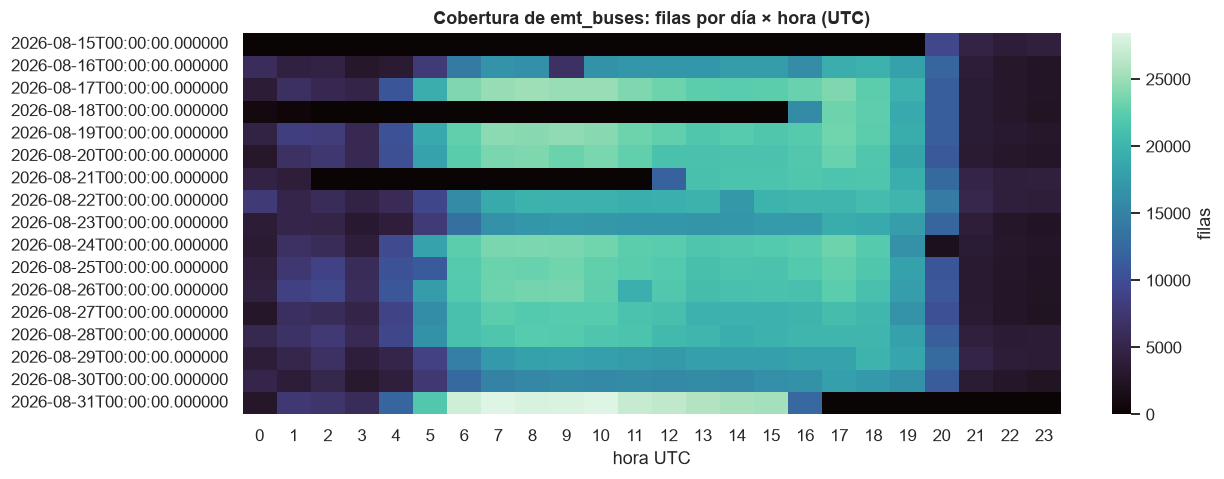

In [9]:
eu.heatmap_cobertura(FUENTE)
plt.show()

In [10]:
eu.huecos(FUENTE).head(10)

,desde,hasta,minutos
0,2026-08-18 01:25:47.554366+00:00,2026-08-18 16:17:27.159732+00:00,891.667
1,2026-08-21 01:32:36.733853+00:00,2026-08-21 12:28:09.662136+00:00,655.550
2,2026-08-24 19:51:05.486352+00:00,2026-08-24 20:44:08.642639+00:00,53.050
3,2026-08-16 09:15:09.051549+00:00,2026-08-16 09:38:51.244284+00:00,23.700
4,2026-08-25 05:11:30.193645+00:00,2026-08-25 05:35:03.119289+00:00,23.550
5,2026-08-16 08:57:55.348338+00:00,2026-08-16 09:14:08.819323+00:00,16.217
6,2026-08-28 03:01:58.245688+00:00,2026-08-28 03:15:05.397710+00:00,13.117
7,2026-08-30 03:22:27.328111+00:00,2026-08-30 03:35:03.544504+00:00,12.600
8,2026-08-18 23:50:48.062631+00:00,2026-08-19 00:03:07.422969+00:00,12.317
9,2026-08-31 03:01:02.186617+00:00,2026-08-31 03:12:37.286644+00:00,11.583


## 4. Trampa 002 — la alternancia de convención horaria

La EMT publica el `datetime` de cada fila unas veces en UTC y otras en hora local
naive, **cambiando de un sondeo al siguiente**. El colector lo resuelve por
snapshot comparándolo con su propio reloj (`resolver_convencion` en
`ingest/sources.py`) y deja constancia en `tz_convencion`.

Lo que se mide aquí es cuántas veces cambia la convención entre sondeos
consecutivos. Si fuera un desfase estable, corregir con una constante bastaría; si
alterna, corregir con una constante deja desplazadas dos horas todas las filas de
la convención minoritaria.

In [11]:
eu.sql(
    "SELECT tz_convencion, count(*) AS filas, count(DISTINCT snapshot_id) AS snapshots FROM {f} GROUP BY 1 ORDER BY 2 DESC",
    f=FUENTE,
)

,tz_convencion,filas,snapshots
0,LOCAL_NAIVE,4401229,34425
1,YA_EN_UTC,761802,6493


In [12]:
alt = eu.sql(
    """
    WITH s AS (
        SELECT snapshot_id,
               any_value(tz_convencion) AS conv,
               min(ts_ingest_utc) AS t
        FROM {f} GROUP BY 1
    ), o AS (
        SELECT conv, lag(conv) OVER (ORDER BY t) AS previa FROM s
    )
    SELECT count(*) AS transiciones,
           sum(CASE WHEN conv <> previa THEN 1 ELSE 0 END) AS alternancias,
           100.0 * sum(CASE WHEN conv <> previa THEN 1 ELSE 0 END) / count(*) AS pct
    FROM o WHERE previa IS NOT NULL
    """,
    f=FUENTE,
)
alt.round(2)

,transiciones,alternancias,pct
0,40913,"7,576.000",18.520


In [13]:
# La latencia por convención es el chivato de que la resolución acertó: si una
# de las dos ramas tuviera latencias en torno a ±7200 s, estaría mal resuelta.
eu.sql(
    """
    SELECT tz_convencion,
           count(*) AS filas,
           median(latencia_s) AS mediana_s,
           min(latencia_s) AS min_s,
           max(latencia_s) AS max_s
    FROM {f} GROUP BY 1
    """,
    f=FUENTE,
).round(1)

,tz_convencion,filas,mediana_s,min_s,max_s
0,YA_EN_UTC,761802,25.700,-7.800,149.900
1,LOCAL_NAIVE,4401229,26.000,-9.000,477.000


La convención cambia entre sondeos consecutivos en una fracción grande de las
transiciones —del orden de una de cada cinco—, y las dos ramas tienen latencias
medianas prácticamente idénticas, de unos 26 s. **Eso es la prueba de que la
resolución acertó**: si una de las dos estuviera mal resuelta, su latencia
mediana estaría desplazada 7200 s (dos horas), no coincidiría con la otra al
segundo.

El mínimo ligeramente negativo (unos −9 s) es deriva de reloj entre la fuente y
el colector, no un fallo de convención: el error de convención se mide en horas.

## 5. Trampa 001 — `gid` no identifica al vehículo

Si `gid` fuera un identificador de vehículo, dos sondeos consecutivos
compartirían casi todos sus valores. Se comprueba directamente: intersección de
`gid` entre snapshots contiguos.

In [14]:
inter = eu.sql(
    """
    WITH s AS (
        SELECT snapshot_id, min(ts_ingest_utc) AS t FROM {f} GROUP BY 1 ORDER BY t LIMIT 6
    ), pares AS (
        SELECT snapshot_id AS a, lead(snapshot_id) OVER (ORDER BY t) AS b FROM s
    )
    SELECT p.a, p.b,
           (SELECT count(*) FROM {f} x WHERE x.snapshot_id = p.a) AS filas_a,
           (SELECT count(*) FROM {f} y WHERE y.snapshot_id = p.b) AS filas_b,
           (SELECT count(*) FROM (
                SELECT gid FROM {f} x WHERE x.snapshot_id = p.a
                INTERSECT
                SELECT gid FROM {f} y WHERE y.snapshot_id = p.b)) AS gids_comunes
    FROM pares p WHERE p.b IS NOT NULL
    """,
    f=FUENTE,
)
inter

,a,b,filas_a,filas_b,gids_comunes
0,1660008502,1660008644,142,142,0
1,1660008644,1660008786,142,142,0
2,1660008786,1660008928,142,141,0
3,1660008928,1660009069,141,139,0
4,1660009069,1660009208,139,139,0


Intersección cero (o casi) confirma la trampa: `gid` sirve como identificador de
fila dentro del refresco y para nada más. La identidad del vehículo hay que
**inferirla**, que es lo que hace `tracking.py`, y por eso su corrección se mide
con verdad-terreno sintética en `tests/conftest.py`.

## 6. Univariante numérico

In [15]:
eu.resumen_numerico(FUENTE, ["latencia_s", "lat", "lon"]).round(4)

,n,media,mediana,moda,desv,min,p01,p25,p75,p99,max,iqr,atipicos_iqr,pct_atipicos
columna,,,,,,,,,,,,,,
latencia_s,5163031,26.345,25.941,10.666,12.310,-8.952,3.701,18.015,33.874,51.921,476.972,15.859,40774,0.790
lat,5163031,39.467,39.470,39.471,0.030,39.194,39.308,39.462,39.479,39.528,39.543,0.018,381083,7.381
lon,5163031,-0.365,-0.367,-0.371,0.027,-0.515,-0.414,-0.386,-0.341,-0.311,-0.264,0.045,3706,0.072


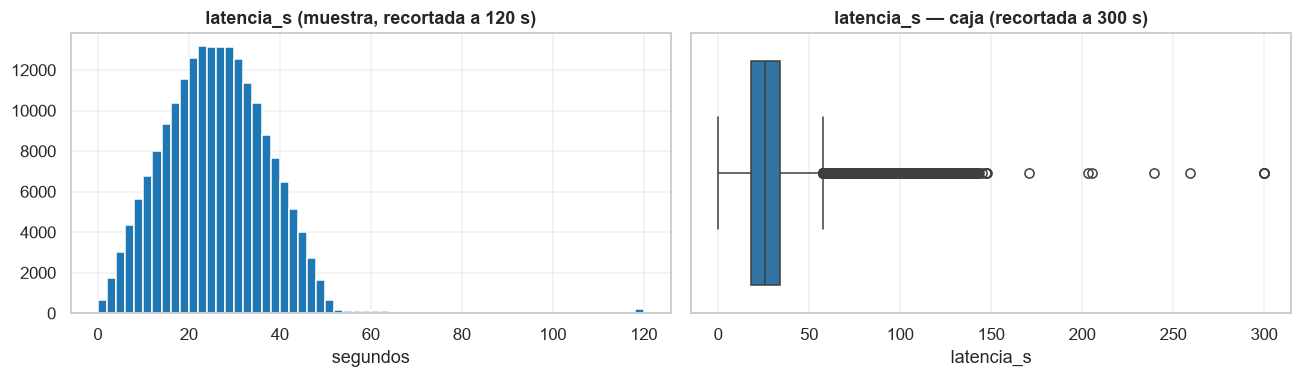

In [16]:
lat_s = eu.sql(
    "SELECT latencia_s FROM {f} USING SAMPLE 200000 ROWS", f=FUENTE
)["latencia_s"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.hist(lat_s.clip(0, 120), bins=60, color=eu.PALETA[FUENTE])
a1.set_title("latencia_s (muestra, recortada a 120 s)")
a1.set_xlabel("segundos")
sns.boxplot(x=lat_s.clip(0, 300), ax=a2, color=eu.PALETA[FUENTE])
a2.set_title("latencia_s — caja (recortada a 300 s)")
plt.tight_layout()
plt.show()

La latencia es la edad del dato cuando lo capturamos. Su mediana es el suelo de
cualquier promesa de tiempo real: no se puede anticipar con más finura que el
retardo con el que llega la observación.

## 7. Univariante categórico: líneas y trayectos

In [17]:
eu.frecuencias(FUENTE, "linea", top=20)

,valor,filas,pct,pct_acum
0,C3,390312,7.560,7.560
1,99,341374,6.612,14.172
2,31,304202,5.892,20.064
3,92,301572,5.841,25.905
4,95,300844,5.827,31.731
5,93,274142,5.310,37.041
6,19,250627,4.854,41.895
7,32,241200,4.672,46.567
8,16,191551,3.710,50.277
9,71,182061,3.526,53.803


In [18]:
cob = eu.sql(
    """
    SELECT linea,
           count(*) AS filas,
           count(DISTINCT snapshot_id) AS snapshots_presente,
           count(DISTINCT trayecto) AS trayectos
    FROM {f} GROUP BY 1 ORDER BY filas DESC
    """,
    f=FUENTE,
)
snaps = eu.sql("SELECT count(DISTINCT snapshot_id) AS n FROM {f}", f=FUENTE).n.iloc[0]
cob["pct_snapshots"] = 100 * cob["snapshots_presente"] / snaps
print(f"{len(cob)} líneas, {cob['trayectos'].sum()} pares línea×trayecto")
cob.head(15).round(1)

42 líneas, 114 pares línea×trayecto


,linea,filas,snapshots_presente,trayectos,pct_snapshots
0,C3,390312,39928,4,97.600
1,99,341374,38782,4,94.800
2,31,304202,34106,2,83.400
3,92,301572,34896,3,85.300
4,95,300844,32745,5,80.000
5,93,274142,38676,5,94.500
6,19,250627,38120,5,93.200
7,32,241200,32746,2,80.000
8,16,191551,39159,2,95.700
9,71,182061,33947,4,83.000


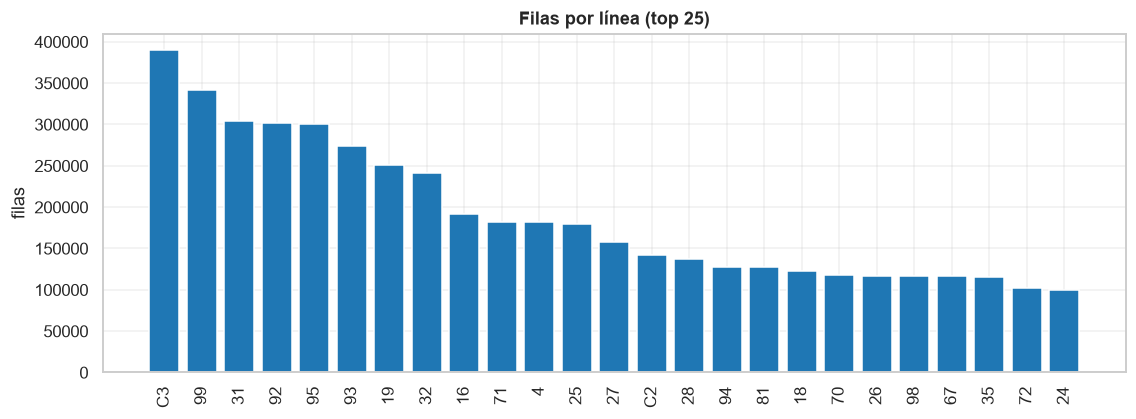

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
top = cob.head(25)
ax.bar(top["linea"].astype(str), top["filas"], color=eu.PALETA[FUENTE])
ax.set_title("Filas por línea (top 25)")
ax.set_ylabel("filas")
plt.xticks(rotation=90)
plt.show()

Las líneas con muy pocas filas no son líneas mal capturadas: son líneas con menos
vehículos o con servicio limitado a ciertas franjas. **Es un aviso para el
etiquetado**: una línea con 300 observaciones no sostiene una métrica por línea, y
promediar sobre todas mezcla poblaciones muy distintas.

## 8. Perfil temporal

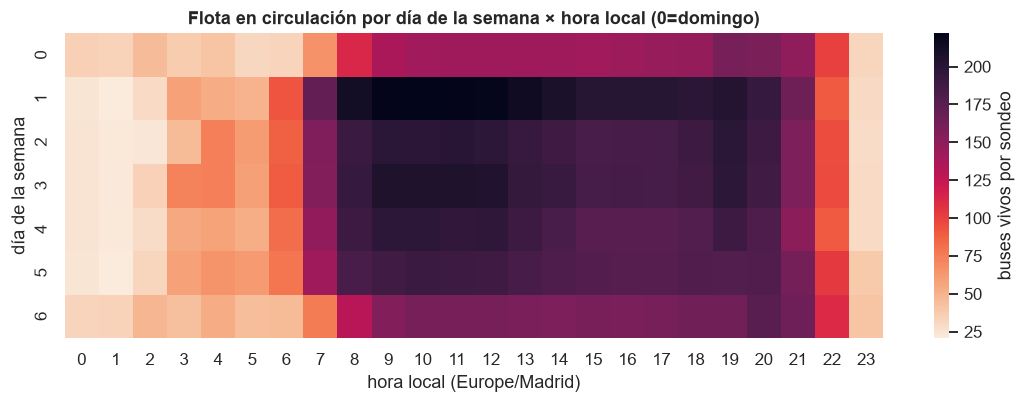

In [20]:
perfil = eu.sql(
    """
    SELECT hour(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS hora_local,
           dayofweek(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS dia_semana,
           count(*) AS filas,
           count(DISTINCT snapshot_id) AS snapshots
    FROM {f} GROUP BY 1, 2
    """,
    f=FUENTE,
)
perfil["buses_por_snapshot"] = perfil["filas"] / perfil["snapshots"]
pivote = perfil.pivot(index="dia_semana", columns="hora_local", values="buses_por_snapshot")

fig, ax = plt.subplots(figsize=(12, 3.6))
sns.heatmap(pivote, cmap="rocket_r", ax=ax, cbar_kws={"label": "buses vivos por sondeo"})
ax.set_title("Flota en circulación por día de la semana × hora local (0=domingo)")
ax.set_xlabel("hora local (Europe/Madrid)")
ax.set_ylabel("día de la semana")
plt.show()

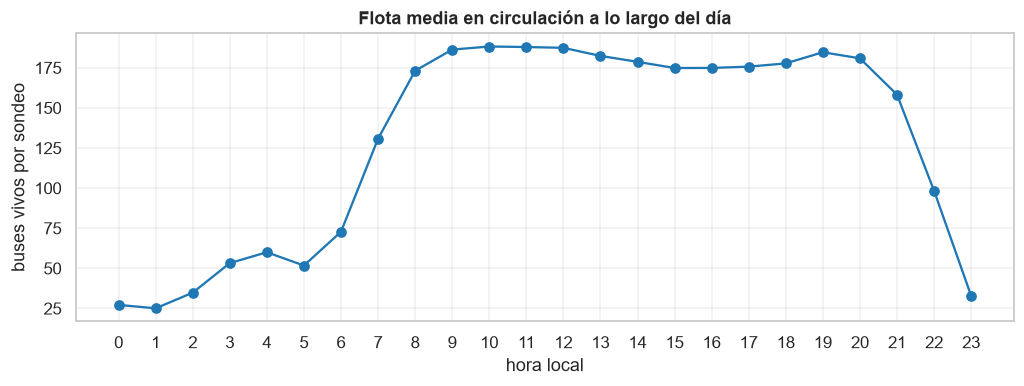

In [21]:
porh = perfil.groupby("hora_local", as_index=False)["buses_por_snapshot"].mean()
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(porh["hora_local"], porh["buses_por_snapshot"], marker="o", color=eu.PALETA[FUENTE])
ax.set_xlabel("hora local")
ax.set_ylabel("buses vivos por sondeo")
ax.set_title("Flota media en circulación a lo largo del día")
ax.set_xticks(range(0, 24))
plt.show()

El número de buses vivos por sondeo es la **densidad efectiva de la muestra**. Las
horas valle tienen tan pocos vehículos que cualquier estadística horaria del
retraso en esa franja va a ser ruidosa; conviene tenerlo presente antes de partir
el conjunto por hora.

## 9. Distribución espacial y trampa 006

In [22]:
eu.bbox(FUENTE)

,con_posicion,lat_min,lat_max,lon_min,lon_max,sin_posicion
0,5163031,39.194,39.543,-0.515,-0.263,0.000


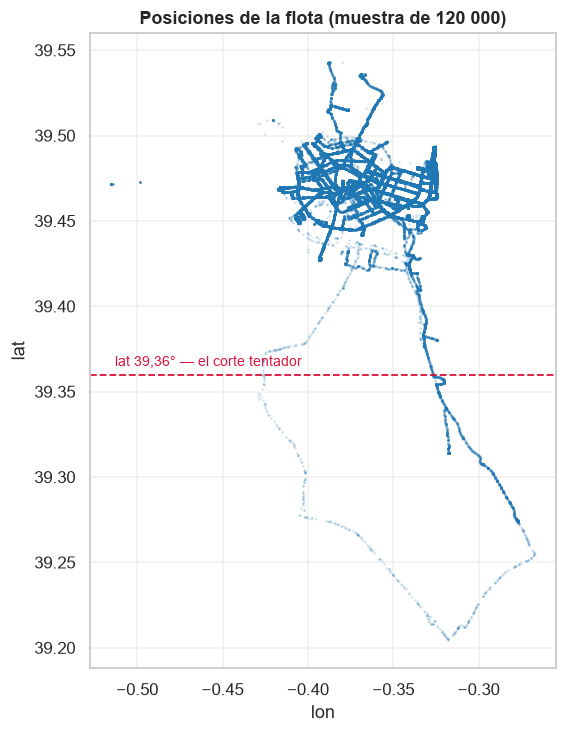

In [23]:
pos = eu.sql(
    "SELECT lat, lon, linea FROM {f} USING SAMPLE 120000 ROWS", f=FUENTE
).dropna(subset=["lat", "lon"])

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.scatter(pos["lon"], pos["lat"], s=0.6, alpha=0.15, color=eu.PALETA[FUENTE])
ax.axhline(39.36, color="crimson", lw=1.2, ls="--")
ax.text(pos["lon"].min(), 39.365, " lat 39,36° — el corte tentador", color="crimson", fontsize=9)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal")
ax.set_title("Posiciones de la flota (muestra de 120 000)")
plt.show()

In [ ]:
sur = eu.sql(
    """
    SELECT linea, count(*) AS filas, min(lat) AS lat_min, max(lat) AS lat_max
    FROM {f} WHERE lat < 39.36 GROUP BY 1 ORDER BY filas DESC
    """,
    f=FUENTE,
)
total = eu.sql("SELECT count(*) AS n FROM {f}", f=FUENTE).n.iloc[0]
print(f"{sur['filas'].sum():,} filas al sur de 39,36° ({100 * sur['filas'].sum() / total:.2f} % del total)")
sur

106,170 filas al sur de 39,36° (2.06 % del total)


,linea,filas,lat_min,lat_max
0,25,74018,39.194,39.360
1,24,31641,39.194,39.360
2,99,188,39.205,39.360
3,98,115,39.205,39.359
4,96,70,39.274,39.360
5,28,55,39.206,39.358
6,70,38,39.240,39.356
7,27,26,39.314,39.359
8,71,19,39.314,39.359


: 

**No filtrar por caja geográfica** (trampa 006). Las posiciones del sur son las
líneas que bajan a El Perellonet: recortarlas no limpia ruido, elimina los
corredores periurbanos —justo donde el tráfico y el retraso se comportan distinto—
y sesga la muestra hacia el centro bien cubierto. Si hay que descartar posiciones,
el criterio tiene que ser de coherencia cinemática (saltos imposibles entre
observaciones consecutivas), no de geografía.

## 10. Hallazgos

1. **La alternancia horaria está viva en el corpus capturado**, no es una anécdota
   histórica: las dos convenciones conviven en proporciones muy desiguales. Toda
   lectura de `ts_utc` tiene que fiarse de la resolución hecha en ingesta, y
   ninguna corrección posterior con desfase fijo es admisible (trampa 002).
2. **`gid` no reengancha vehículos entre sondeos.** Confirmado midiendo la
   intersección: la identidad hay que inferirla (`tracking.py`), y su error se
   propaga entero a la etiqueta de retraso (trampa 001 + 004).
3. **La flota en circulación varía mucho a lo largo del día.** La muestra no es
   homogénea por franja; las horas valle sostienen mucho menos análisis del que
   parece por el volumen total de filas.
4. **Las líneas están muy desbalanceadas.** Cualquier métrica por línea necesita
   un mínimo de observaciones declarado, y el agregado global está dominado por un
   puñado de líneas.
5. **Las posiciones del sur son reales** (trampa 006), y son un 2 % del corpus
   concentrado en las líneas 24 y 25. El filtro por caja está prohibido en
   `prepare.py`; si hace falta descartar, que sea por cinemática.
6. **La latencia mediana (unos 26 s) marca el suelo de la anticipación.** Ninguna
   promesa de predicción puede ser más fina que el retardo con el que llega la
   observación.
7. **`(snapshot_id, gid)` no es una clave única.** Son pocas filas, pero no cero:
   hay que deduplicar explícitamente y contar lo eliminado, no suponer unicidad.